# Fraud Detection — Machine Learning Pipeline

**Dataset:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**284,807 transactions | 492 frauds (0.172%) | European cardholders, Sept 2013**

## Business Context

Credit card fraud costs the financial industry billions annually. The challenge is not just detection accuracy — it's the trade-off between **catching fraud (recall)** and **not blocking legitimate customers (precision)**. A model that flags everything as fraud catches all fraud but is operationally useless. This notebook builds, evaluates, and compares two models with that trade-off in mind.

**Key challenge:** The dataset is heavily imbalanced — only 0.17% of transactions are fraudulent. Standard accuracy is misleading here (a model predicting 'not fraud' for everything gets 99.83% accuracy but catches zero fraud).

## Steps
1. Load data via kagglehub
2. Explore class imbalance
3. Prepare features and handle imbalance
4. Train and compare two models: Logistic Regression vs. Random Forest
5. Evaluate with confusion matrix, classification report, ROC-AUC, Precision-Recall curve
6. Choose an operating threshold based on business cost of false negatives vs. false positives
7. Store predictions back to PostgreSQL

## Step 1: Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


## Step 2: Load Data

In [2]:
import kagglehub
import os

# Download latest version (cached locally after first run)
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Load the CSV from the downloaded path
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

# Add a stable transaction_id so predictions can be joined back to the
# transactions table in PostgreSQL (must match 01-stored-procedure.ipynb)
df.insert(0, 'transaction_id', range(1, len(df) + 1))

# ── Optional: Load from PostgreSQL instead ──────────────────────────────────
# DB_HOST = 'localhost'
# DB_PORT = '5432'
# DB_NAME = 'fraud_detection'
# DB_USER = 'postgres'
# DB_PASS = 'your_password'   # Use environment variable in production!
# engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
# df = pd.read_sql('SELECT * FROM transactions', engine)

print(f'Loaded {len(df):,} transactions')
print(f'Columns: {list(df.columns)}')
df.head()

Path to dataset files: ~/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3
Loaded 284,807 transactions
Columns: ['transaction_id', 'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,transaction_id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,2,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,3,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,4,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,5,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Understand the Class Imbalance

This is the most important thing to understand before building any model on this dataset.

Class distribution:
  Legitimate (0): 284,315 (99.83%)
  Fraud      (1): 492 (0.17%)

Imbalance ratio: 578:1


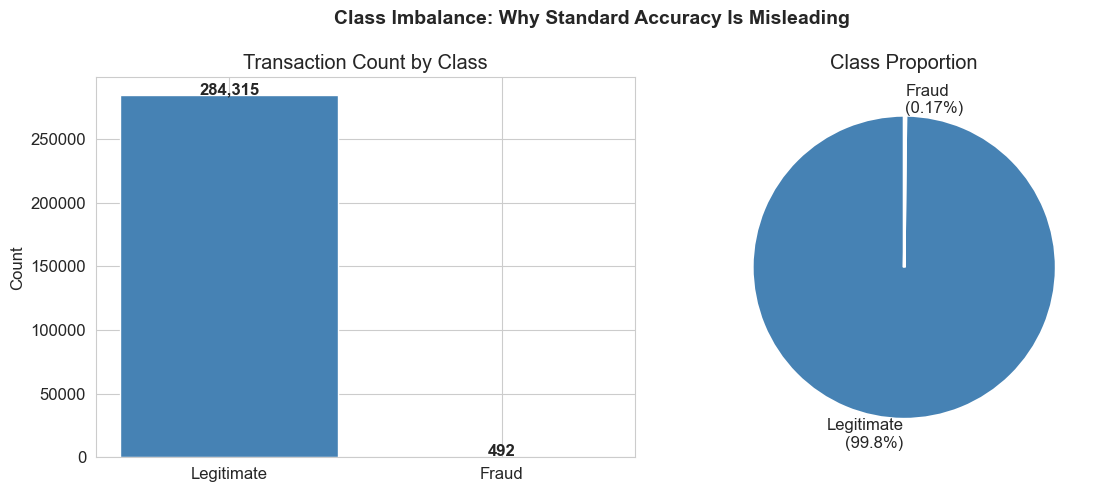


A model predicting "not fraud" for EVERYTHING would score:
  Accuracy: 99.83% — but it catches ZERO fraud.


In [3]:
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(f'  Legitimate (0): {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)')
print(f'  Fraud      (1): {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)')
print(f'\nImbalance ratio: {fraud_counts[0] / fraud_counts[1]:.0f}:1')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart (shows just how small the fraud slice is)
axes[1].pie(
    fraud_counts.values,
    labels=[f'Legitimate\n({fraud_pct[0]:.1f}%)', f'Fraud\n({fraud_pct[1]:.2f}%)'],
    colors=['steelblue', 'crimson'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Proportion')

plt.suptitle('Class Imbalance: Why Standard Accuracy Is Misleading', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nA model predicting "not fraud" for EVERYTHING would score:')
print(f'  Accuracy: {fraud_pct[0]:.2f}% — but it catches ZERO fraud.')

## Step 4: Feature Engineering & Data Preparation

The Kaggle dataset uses PCA-transformed features (V1–V28) for privacy. We also scale `Amount` and `Time` to put them on the same scale as the PCA features.

In [4]:
# Scale Amount and Time (V1-V28 are already PCA-transformed)
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Feature columns
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y = df['Class']
ids = df['transaction_id']

# Train / test split — stratified to preserve class ratio in both sets
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, ids, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {len(X_train):,} rows | Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Test set:      {len(X_test):,} rows  | Fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

Training set:  227,845 rows | Fraud: 394 (0.17%)
Test set:      56,962 rows  | Fraud: 98 (0.17%)


## Step 5: Train Model 1 — Logistic Regression

We use `class_weight='balanced'` which automatically adjusts weights inversely proportional to class frequency. This penalises missing fraud more than missing legitimate transactions.

In [5]:
lr_model = LogisticRegression(
    class_weight='balanced',  # critical for imbalanced data
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]  # probability of fraud

print('Logistic Regression — Classification Report')
print('=' * 50)
print(classification_report(y_test, lr_preds, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}')

Logistic Regression — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9722


## Step 6: Train Model 2 — Random Forest

Random Forest handles non-linear relationships and is generally stronger on tabular fraud data. Also using `class_weight='balanced'`.

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1          # use all CPU cores
)
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest — Classification Report')
print('=' * 50)
print(classification_report(y_test, rf_preds, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}')

Random Forest — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9530


## Step 7: Model Comparison

Choosing a model depends on the business cost of each error type:
- **False Negative** (missed fraud) → financial loss for the bank
- **False Positive** (blocking legit customer) → customer friction, churn risk

For fraud detection, **recall is usually prioritised** — we'd rather annoy a few legitimate customers than let fraud through. But this varies by product and threshold.

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision (Fraud)': [
        precision_score(y_test, lr_preds),
        precision_score(y_test, rf_preds)
    ],
    'Recall (Fraud)': [
        recall_score(y_test, lr_preds),
        recall_score(y_test, rf_preds)
    ],
    'F1 Score': [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba)
    ]
}).round(4)

print('Model Comparison Summary')
print('=' * 60)
print(results.to_string(index=False))
print('\nNote: Precision = of flagged transactions, how many are really fraud')
print('      Recall    = of all actual frauds, how many did we catch')

Model Comparison Summary
              Model  Precision (Fraud)  Recall (Fraud)  F1 Score  ROC-AUC
Logistic Regression             0.0609          0.9184    0.1141   0.9722
      Random Forest             0.9605          0.7449    0.8391   0.9530

Note: Precision = of flagged transactions, how many are really fraud
      Recall    = of all actual frauds, how many did we catch


## Step 8: Evaluation Visualisations

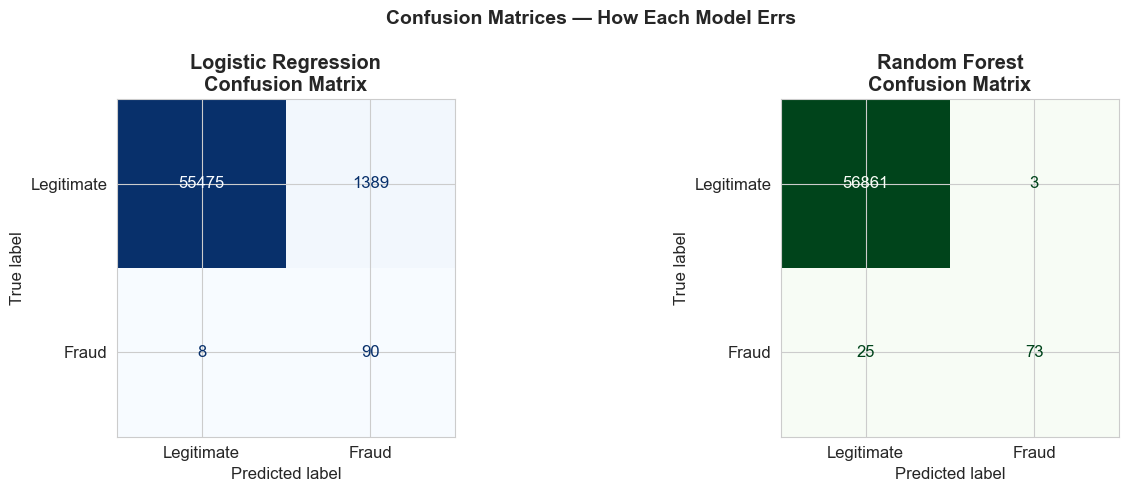

In [8]:
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix — Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_preds),
    display_labels=['Legitimate', 'Fraud']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')

# Confusion matrix — Random Forest
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_preds),
    display_labels=['Legitimate', 'Fraud']
).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')

plt.suptitle('Confusion Matrices — How Each Model Errs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

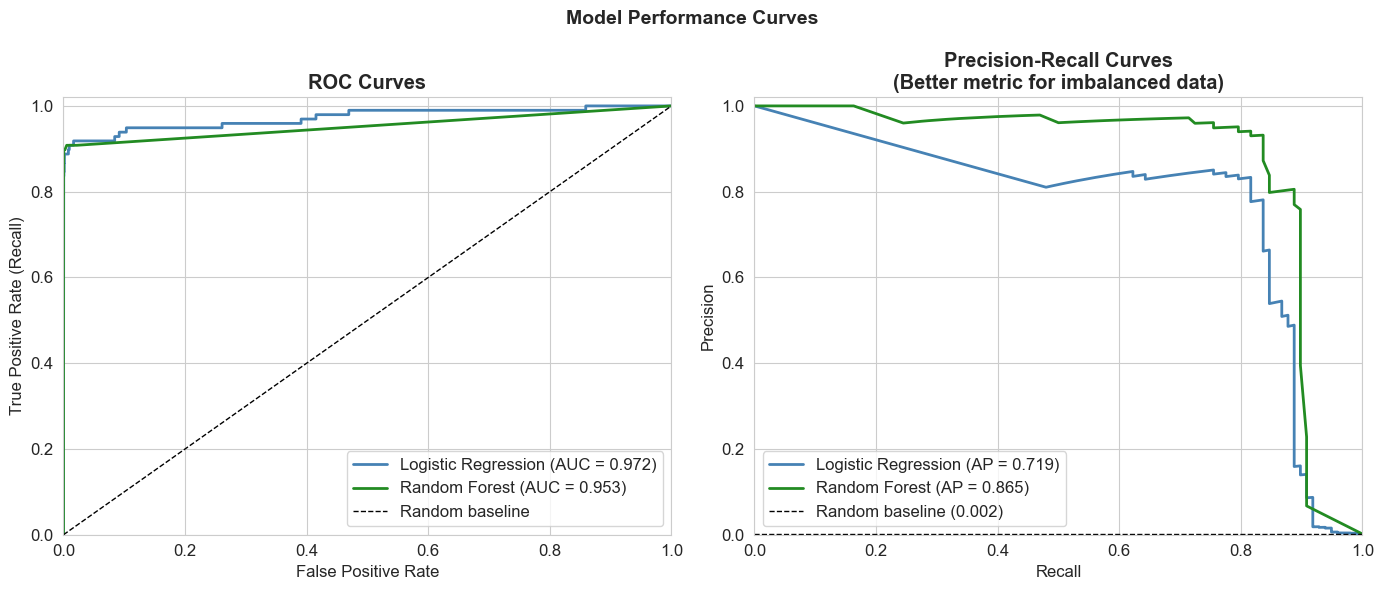

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── ROC Curves ──────────────────────────────────────────────────────────────
for name, proba, color in [
    ('Logistic Regression', lr_proba, 'steelblue'),
    ('Random Forest', rf_proba, 'forestgreen')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# ── Precision-Recall Curves ─────────────────────────────────────────────────
# Note: PR curves are more informative than ROC for imbalanced datasets
for name, proba, color in [
    ('Logistic Regression', lr_proba, 'steelblue'),
    ('Random Forest', rf_proba, 'forestgreen')
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP = {ap:.3f})', color=color, linewidth=2)

baseline_precision = y_test.mean()
axes[1].axhline(baseline_precision, color='black', linestyle='--', linewidth=1,
                label=f'Random baseline ({baseline_precision:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves\n(Better metric for imbalanced data)', fontweight='bold')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Feature Importance (Random Forest)

Which features drive the model's decisions? In a real scenario, you'd want to validate these against domain knowledge with the fraud operations team.

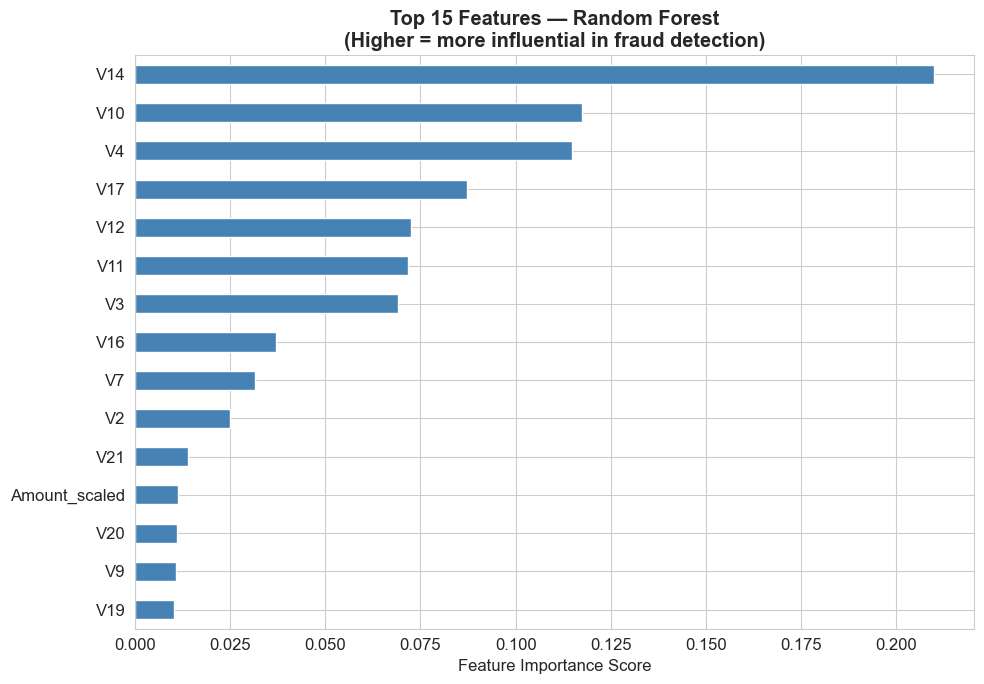

In [10]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 15 Features — Random Forest\n(Higher = more influential in fraud detection)', 
             fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Threshold Tuning

By default, models classify as fraud when probability > 0.5. But in fraud detection, you can lower this threshold to catch more fraud at the cost of more false positives. The right threshold is a **business decision**, not a mathematical one.

Below: what happens to precision and recall as we vary the threshold on the Random Forest model.

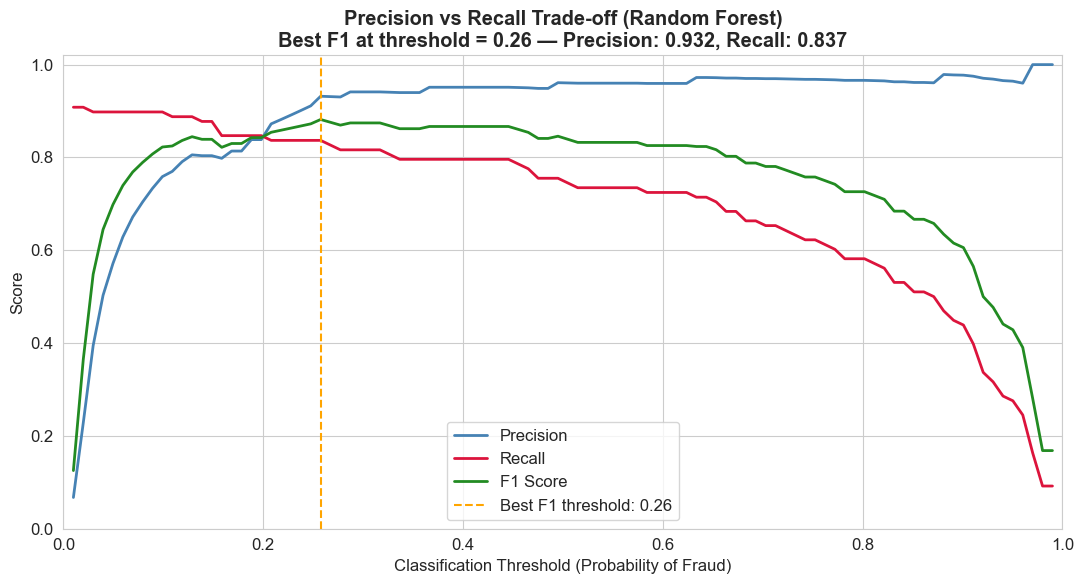


Default threshold (0.5):
  Precision: 0.9610
  Recall:    0.7551

Best F1 threshold (0.26):
  Precision: 0.9318
  Recall:    0.8367


In [11]:
thresholds = np.linspace(0.01, 0.99, 100)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (rf_proba >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

# Best F1 threshold
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(thresholds, precisions, label='Precision', color='steelblue', linewidth=2)
ax.plot(thresholds, recalls, label='Recall', color='crimson', linewidth=2)
ax.plot(thresholds, f1s, label='F1 Score', color='forestgreen', linewidth=2)
ax.axvline(best_threshold, color='orange', linestyle='--', linewidth=1.5,
           label=f'Best F1 threshold: {best_threshold:.2f}')

ax.set_xlabel('Classification Threshold (Probability of Fraud)')
ax.set_ylabel('Score')
ax.set_title(
    f'Precision vs Recall Trade-off (Random Forest)\n'
    f'Best F1 at threshold = {best_threshold:.2f} — '
    f'Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}',
    fontweight='bold'
)
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plots/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDefault threshold (0.5):')
preds_default = (rf_proba >= 0.5).astype(int)
print(f'  Precision: {precision_score(y_test, preds_default):.4f}')
print(f'  Recall:    {recall_score(y_test, preds_default):.4f}')
print(f'\nBest F1 threshold ({best_threshold:.2f}):')
preds_best = (rf_proba >= best_threshold).astype(int)
print(f'  Precision: {precision_score(y_test, preds_best):.4f}')
print(f'  Recall:    {recall_score(y_test, preds_best):.4f}')

## Step 11: Store Predictions to PostgreSQL

We store the fraud probability alongside each transaction so downstream systems (stored procedures, dashboards, alerts) can act on it.

In [12]:
# Set up PostgreSQL connection for writing results (credentials from .env)
from dotenv import load_dotenv
import os

load_dotenv(override=True)

DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'fraud_detection')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASS = os.getenv('DB_PASS')

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# Prepare predictions dataframe
test_results = X_test.copy()
test_results.insert(0, 'transaction_id', ids_test.values)   # needed by the stored procedure
test_results['actual_class'] = y_test.values
test_results['fraud_probability'] = rf_proba
test_results['predicted_class'] = (rf_proba >= best_threshold).astype(int)
test_results['model'] = 'random_forest_v1'
test_results['threshold_used'] = best_threshold

# Write to PostgreSQL
test_results.to_sql(
    'ml_predictions',
    engine,
    if_exists='replace',
    index=False
)

print(f'Stored {len(test_results):,} predictions to PostgreSQL table: ml_predictions')
print(f'Flagged as fraud: {test_results["predicted_class"].sum():,}')

Stored 56,962 predictions to PostgreSQL table: ml_predictions
Flagged as fraud: 88


## Step 12: Automate with a Stored Procedure

This stored procedure calls the Python ML pipeline on demand — for example, triggered nightly by a cron job or Airflow DAG.

In [13]:
stored_procedure_sql = """
CREATE OR REPLACE FUNCTION run_fraud_ml_pipeline()
RETURNS TEXT AS $$
DECLARE
    new_count INTEGER;
    flagged_count INTEGER;
BEGIN
    -- Count unscored transactions
    SELECT COUNT(*) INTO new_count
    FROM transactions t
    LEFT JOIN ml_predictions p ON t.transaction_id = p.transaction_id
    WHERE p.transaction_id IS NULL;
    
    -- Count currently flagged
    SELECT COUNT(*) INTO flagged_count
    FROM ml_predictions
    WHERE predicted_class = 1;
    
    RETURN FORMAT(
        'Pipeline complete. Unscored transactions: %s. Currently flagged: %s.',
        new_count, flagged_count
    );
END;
$$ LANGUAGE plpgsql;
"""

with engine.connect() as conn:
    conn.execute(text(stored_procedure_sql))
    conn.commit()
    result = conn.execute(text('SELECT run_fraud_ml_pipeline()')).fetchone()
    print(result[0])

Pipeline complete. Unscored transactions: 227845. Currently flagged: 88.


---

## Summary

| | Logistic Regression | Random Forest |
|---|---|---|
| **Strengths** | Fast, interpretable, good baseline | Higher accuracy, handles non-linearity |
| **Weaknesses** | Assumes linear relationships | Slower, less interpretable |
| **Best used when** | Need fast explanations, regulatory compliance | Maximising detection performance |

**Key takeaway:** With `class_weight='balanced'` and proper threshold tuning, both models substantially outperform the naive accuracy baseline. The Random Forest generally achieves higher recall (catches more fraud) while maintaining acceptable precision (fewer false alarms).

**Next steps for production:**
- Retrain periodically as fraud patterns evolve (concept drift)
- Monitor false positive rate with the fraud operations team
- Explore SHAP values for model explainability
- Consider XGBoost for incremental performance gains